# VAE: Reparameterization Trick with MNIST
## Part 1: The Probabilistic Bottleneck

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

## Device Configuration

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Data Loading and Preprocessing

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f'Train samples: {len(train_data)}')
print(f'Test samples: {len(test_data)}')

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.44MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 147kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.08MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.35MB/s]

Train samples: 60000
Test samples: 10000


## Reparameterization Sampling Layer

In [ ]:
# Reparameterization Trick Implementation

class ReparameterizationLayer(nn.Module):

    def __init__(self, latent_dim):
        super(ReparameterizationLayer, self).__init__()
        self.latent_dim = latent_dim
    
    def forward(self, mu, log_var):

        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

# Standalone reparameterize function
def reparameterize(mu, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    z = mu + eps * std
    return z

## VAE Architecture

In [6]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        
        # Bottleneck: Two parallel layers
        self.mu_layer = nn.Linear(256, latent_dim)
        self.log_var_layer = nn.Linear(256, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28*28),
            nn.Sigmoid()
        )
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_layer(h)
        log_var = self.log_var_layer(h)
        return mu, log_var
    
    def forward(self, x):
        x_flat = x.view(-1, 28*28)
        mu, log_var = self.encode(x_flat)
        z = reparameterize(mu, log_var)
        recon = self.decoder(z)
        recon = recon.view(-1, 1, 28, 28)
        return recon, mu, log_var

model = VAE(latent_dim=20).to(device)
print(model)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (mu_layer): Linear(in_features=256, out_features=20, bias=True)
  (log_var_layer): Linear(in_features=256, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


## Loss Functions

In [7]:
def vae_loss(recon_x, x, mu, log_var):
    bce_loss = nn.BCELoss(reduction='sum')
    recon_loss = bce_loss(recon_x, x)
    kld_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kld_loss, recon_loss, kld_loss

## Optimizer and Training Setup

In [8]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10

## Training Loop

In [9]:
train_losses = []
recon_losses = []
kld_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_recon = 0
    total_kld = 0
    
    for batch_idx, (data, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon, mu, log_var = model(data)
        loss, recon_loss, kld_loss = vae_loss(recon, data, mu, log_var)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kld += kld_loss.item()
    
    avg_loss = total_loss / len(train_data)
    avg_recon = total_recon / len(train_data)
    avg_kld = total_kld / len(train_data)
    
    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kld_losses.append(avg_kld)
    
    print(f'Epoch {epoch+1}: Loss={avg_loss:.4f}, Recon={avg_recon:.4f}, KLD={avg_kld:.4f}')

print('Training completed!')

Epoch 1/10: 100%|██████████| 469/469 [00:07<00:00, 60.92it/s]


Epoch 1: Loss=174.5384, Recon=166.4236, KLD=8.1148


Epoch 2/10: 100%|██████████| 469/469 [00:07<00:00, 63.18it/s]


Epoch 2: Loss=126.6309, Recon=111.2119, KLD=15.4189


Epoch 3/10: 100%|██████████| 469/469 [00:07<00:00, 63.79it/s]


...

Epoch 8: Loss=105.2016, Recon=86.2009, KLD=19.0008


Epoch 9/10: 100%|██████████| 469/469 [00:06<00:00, 67.35it/s]


Epoch 9: Loss=104.4114, Recon=85.2795, KLD=19.1319


Epoch 10/10: 100%|██████████| 469/469 [00:06<00:00, 70.21it/s]

Epoch 10: Loss=103.7272, Recon=84.5168, KLD=19.2104
Training completed!


## Reconstruction Results - 10 Images

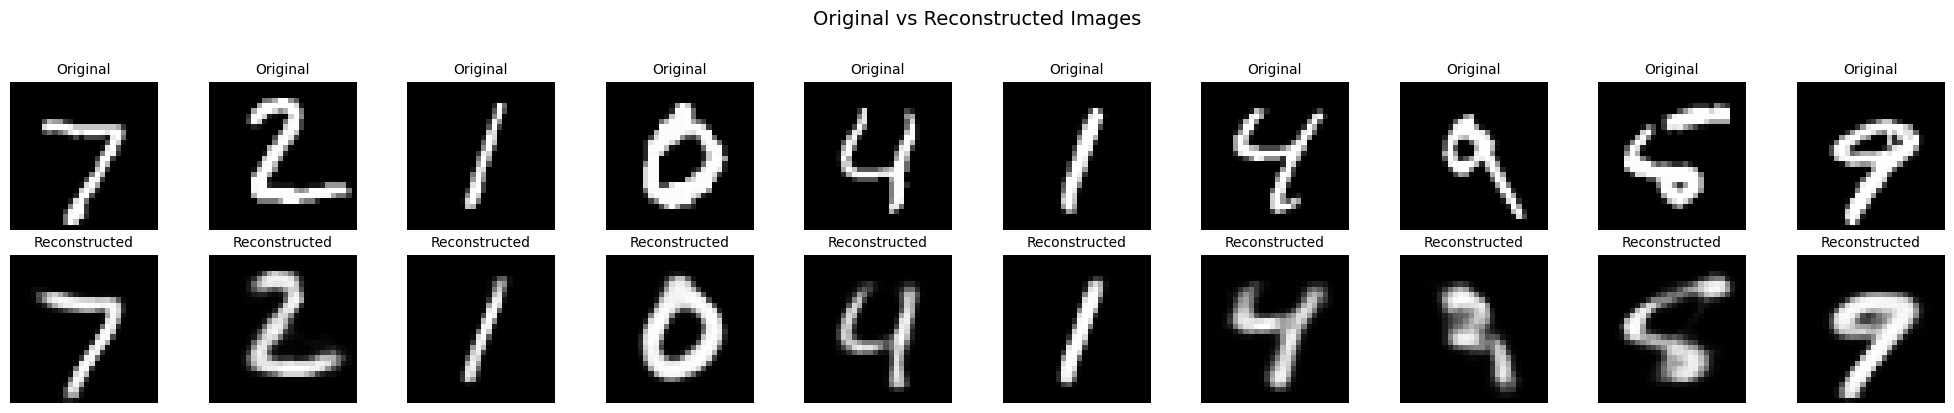

In [10]:
model.eval()

test_batch = next(iter(test_loader))
test_images = test_batch[0][:10].to(device)

with torch.no_grad():
    recon_images, _, _ = model(test_images)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for i in range(10):
    # Original images
    axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title('Original', fontsize=10)
    axes[0, i].axis('off')
    
    # Reconstructed images
    axes[1, i].imshow(recon_images[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title('Reconstructed', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Original vs Reconstructed Images', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()